In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.columns.values

<ArrowStringArray>
['PassengerId',    'Survived',      'Pclass',        'Name',         'Sex',
         'Age',       'SibSp',       'Parch',      'Ticket',        'Fare',
       'Cabin',    'Embarked']
Length: 12, dtype: str

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.drop(columns=['Cabin'],inplace=True)

In [9]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\1698716155.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [10]:
df['Embarked'].value_counts()
df['Embarked'].fillna('S', inplace=True)

C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\2351840006.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna('S', inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [11]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [12]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [13]:
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Embarked']=df['Embarked'].astype('category')
df['Age']=df['Age'].round().astype('Int64')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    Int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Embarked     889 non-null    category
dtypes: Int64(1), category(4), float64(1), int64(3), str(2)
memory usage: 82.6 KB


In [15]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.0,891.000000,891.000000,891.000000
mean,446.000000,29.693277,0.523008,0.381594,32.204208
std,257.353842,14.524527,1.102743,0.806057,49.693429
min,1.000000,0.0,0.000000,0.000000,0.000000
25%,223.500000,20.0,0.000000,0.000000,7.910400
50%,446.000000,28.0,0.000000,0.000000,14.454200
75%,668.500000,38.0,1.000000,0.000000,31.000000
max,891.000000,80.0,8.000000,6.000000,512.329200


Out of 891, 62 people died in the accident


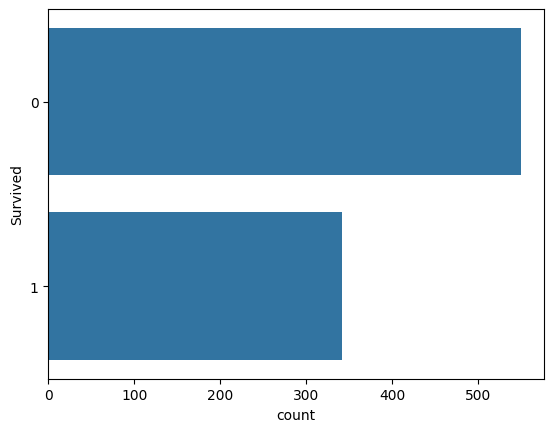

In [16]:
sns.countplot(df['Survived'])
death_percent=round((df['Survived'].value_counts().values[0]/891)*100)
print('Out of 891, {} people died in the accident'.format(death_percent))

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Pclass'>

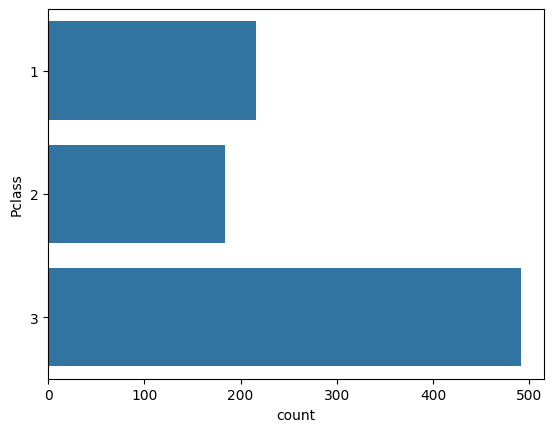

In [17]:
print((df['Pclass'].value_counts()/891)*100)
sns.countplot(df['Pclass'])

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Sex'>

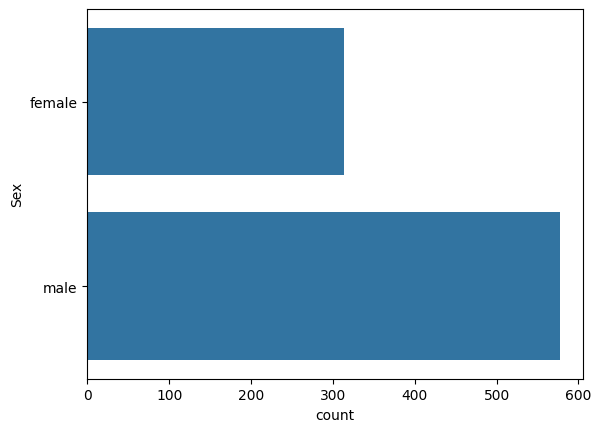

In [18]:
print((df['Sex'].value_counts()/891)*100)
sns.countplot(df['Sex'])

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

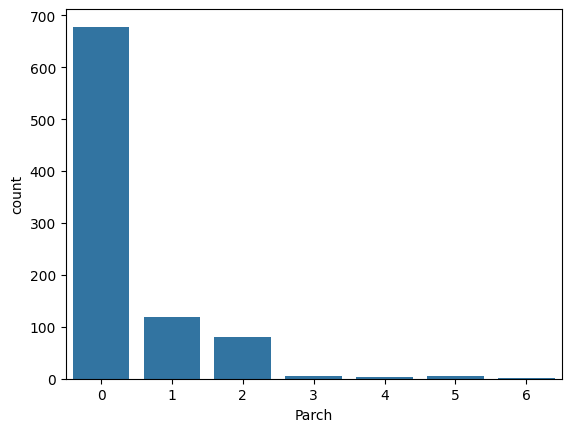

In [19]:
print((df['Parch'].value_counts()/891)*100)
sns.countplot(data=df, x='Parch')

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

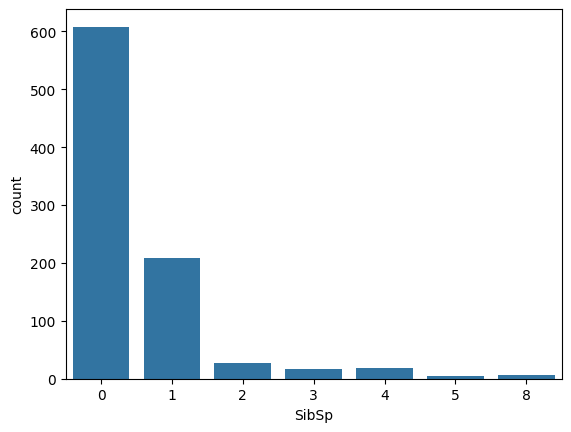

In [20]:
print(df['SibSp'].value_counts())
sns.countplot(data=df, x='SibSp')

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='count', ylabel='Embarked'>

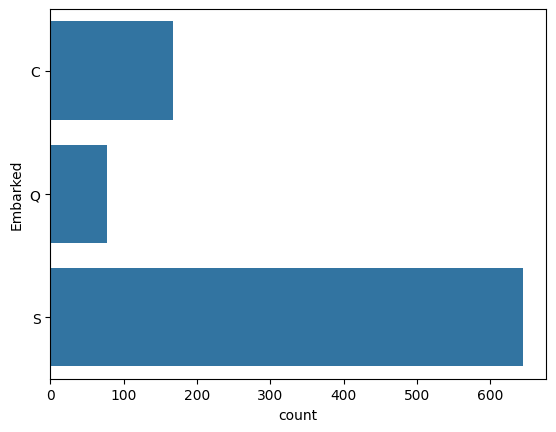

In [21]:
print((df['Embarked'].value_counts()/891)*100)
sns.countplot(df['Embarked'])

C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\350049838.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


0.39066087788180154
0.17572389001200728


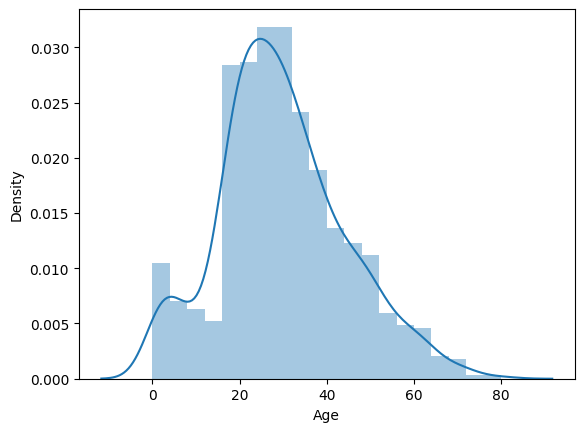

In [22]:
sns.distplot(df['Age'])
print(df['Age'].skew())
print(df['Age'].kurt())

<Axes: ylabel='Age'>

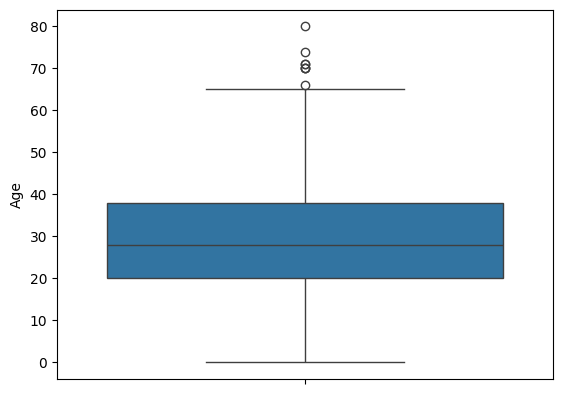

In [23]:
sns.boxplot(df['Age'])

C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\3425841524.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

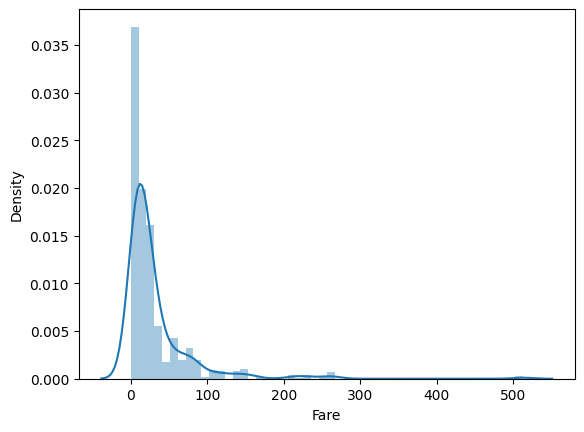

In [24]:
sns.distplot(df['Fare'])

In [25]:
print(df['Fare'].skew())
print(df['Fare'].kurt())

4.787316519674893
33.39814088089868


<Axes: ylabel='Fare'>

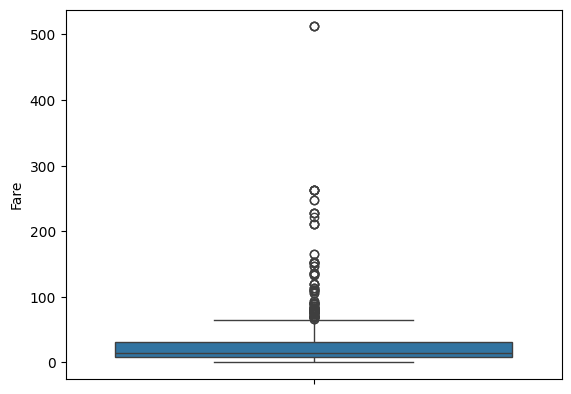

In [26]:
sns.boxplot(df['Fare'])

In [27]:
print('People with fare in between $200 and $400',df[(df['Fare']>200) & (df['Fare']<300)].shape[0])
print('People with fare greater than $300',df[df['Fare']>300].shape[0])

People with fare in between $200 and $400 17
People with fare greater than $300 3


Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


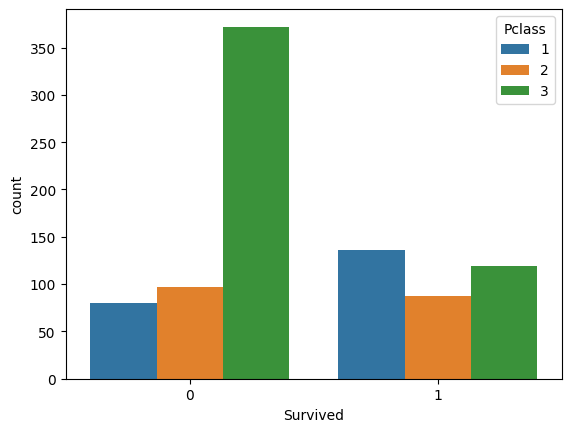

In [28]:
sns.countplot(data=df, x='Survived', hue=df['Pclass'])
pd.crosstab(df['Pclass'], df['Survived']).apply(lambda r: round((r/r.sum())*100, 1), axis=1)

Survived,0,1
Sex,,
female,25.8,74.2
male,81.1,18.9


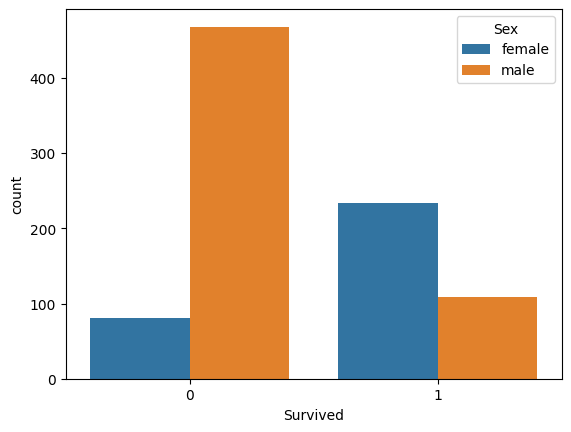

In [29]:
sns.countplot(data=df, x='Survived', hue=df['Sex'])
pd.crosstab(df['Sex'], df['Survived']).apply(lambda r: round((r/r.sum())*100, 1), axis=1)

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.3,33.7


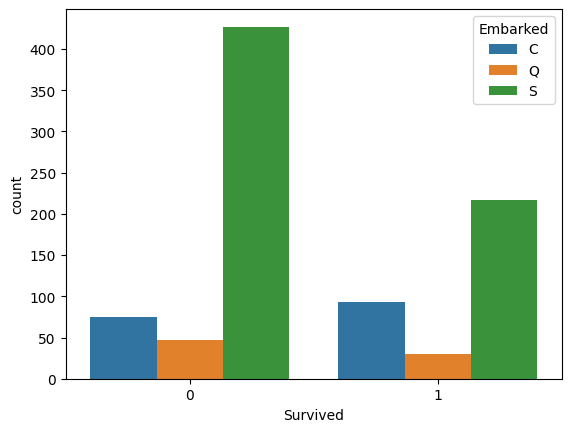

In [30]:
sns.countplot(data=df, x='Survived', hue=df['Embarked'])
pd.crosstab(df['Embarked'], df['Survived']).apply(lambda r: round((r/r.sum())*100, 1), axis=1)

C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\3428990437.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Age'])
C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\3428990437.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==1]['Age'])


<Axes: xlabel='Age', ylabel='Density'>

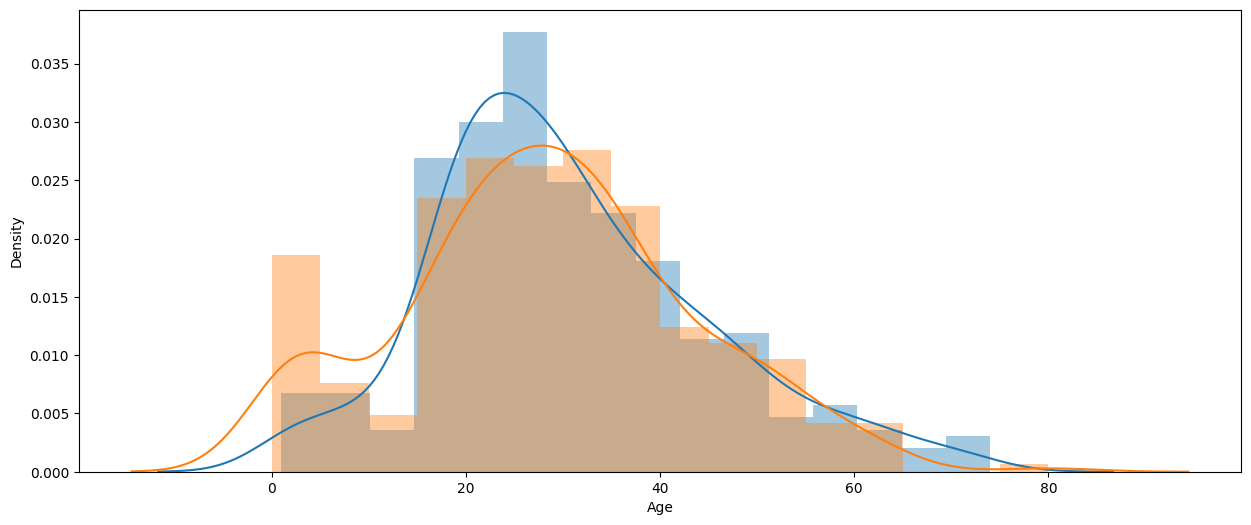

In [31]:
plt.figure(figsize=(15,6))
sns.distplot(df[df['Survived']==0]['Age'])
sns.distplot(df[df['Survived']==1]['Age'])

C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\1419208532.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Fare'])
C:\Users\IMA~GINE\AppData\Local\Temp\ipykernel_12596\1419208532.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==1]['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

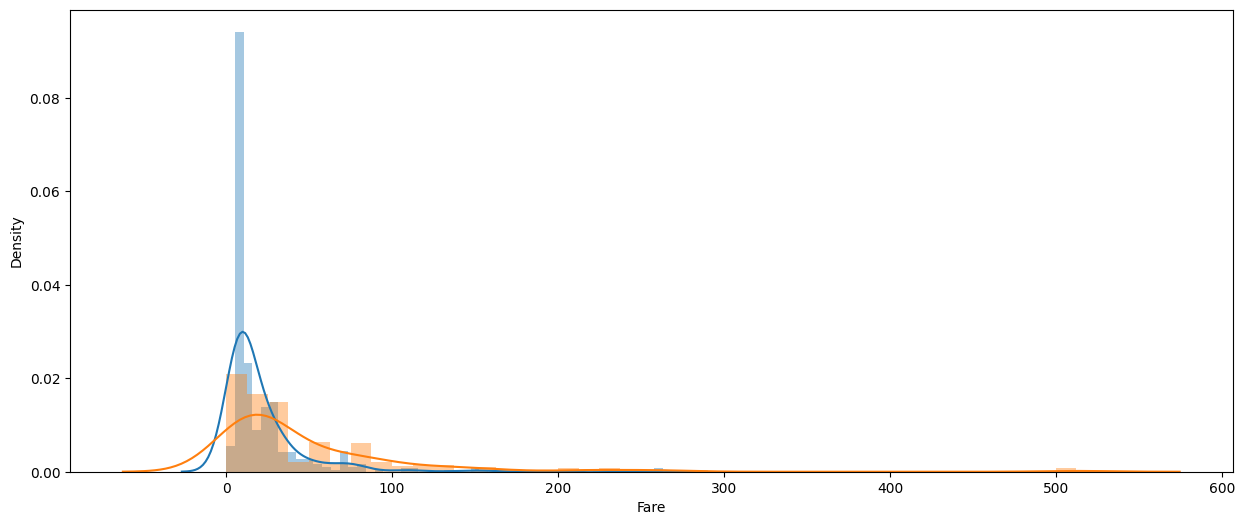

In [32]:
plt.figure(figsize=(15,6))
sns.distplot(df[df['Survived']==0]['Fare'])
sns.distplot(df[df['Survived']==1]['Fare'])

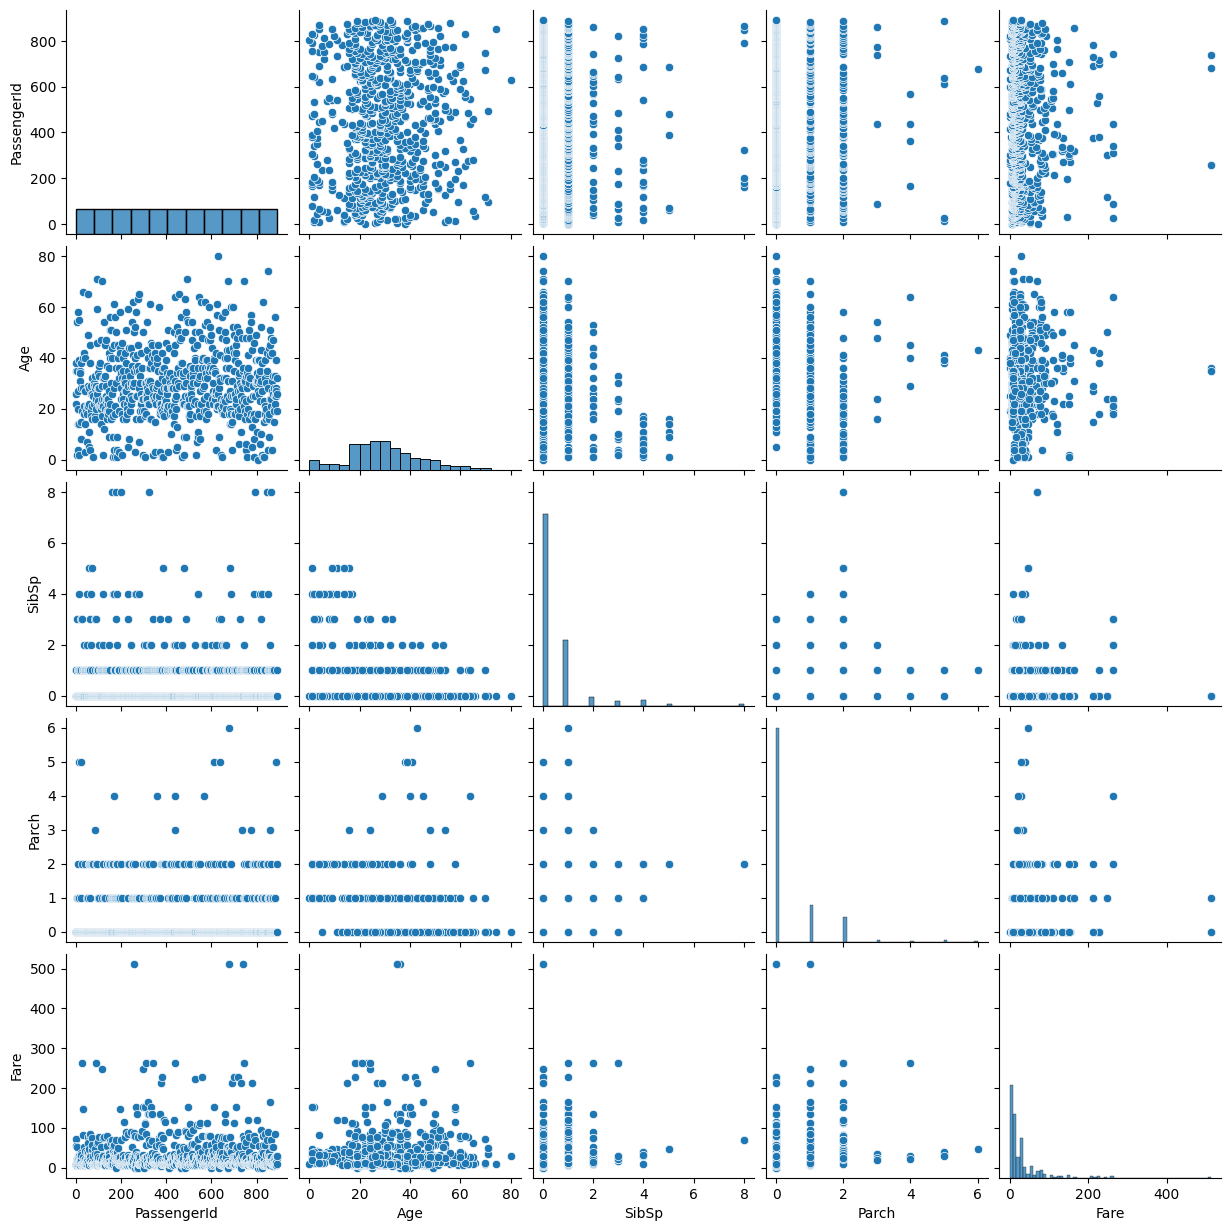

In [33]:
sns.pairplot(df)

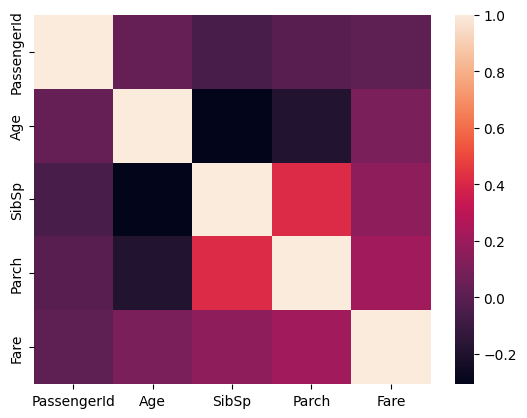

In [34]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

In [35]:
df['family_size']=df['Parch'] + df['SibSp']

In [36]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
217,218,0,2,"Jacobsohn, Mr. Sidney Samuel",male,42,1,0,243847,27.0000,S,1
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40,0,2,A/5. 851,14.5000,S,2
457,458,1,1,"Kenyon, Mrs. Frederick R (Marion)",female,<NA>,1,0,17464,51.8625,S,1
861,862,0,2,"Giles, Mr. Frederick Edward",male,21,1,0,28134,11.5000,S,1
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24,0,1,PC 17558,247.5208,C,1


In [37]:
def family_type(number):
    if number==0:
        return "Alone"
    elif number>0 and number<=4:
        return "Medium"
    else:
        return "Large"


In [38]:
df['family_type']=df['family_size'].apply(family_type)

In [39]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,family_type
389,390,1,2,"Lehmann, Miss. Bertha",female,17,0,0,SC 1748,12.00,C,0,Alone
654,655,0,3,"Hegarty, Miss. Hanora ""Nora""",female,18,0,0,365226,6.75,Q,0,Alone
466,467,0,2,"Campbell, Mr. William",male,<NA>,0,0,239853,0.00,S,0,Alone
407,408,1,2,"Richards, Master. William Rowe",male,3,1,1,29106,18.75,S,2,Medium
669,670,1,1,"Taylor, Mrs. Elmer Zebley (Juliet Cummins Wright)",female,<NA>,1,0,19996,52.00,S,1,Medium


In [40]:
df.drop(columns=['SibSp', 'Parch', 'family_size'],inplace=True)


In [41]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,family_type
271,272,1,3,"Tornquist, Mr. William Henry",male,25,LINE,0.000,S,Alone
16,17,0,3,"Rice, Master. Eugene",male,2,382652,29.125,Q,Large
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57,219533,12.350,Q,Alone
273,274,0,1,"Natsch, Mr. Charles H",male,37,PC 17596,29.700,C,Medium
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39,112050,0.000,S,Alone


In [42]:
pd.crosstab(df['family_type'], df['Survived']).apply(lambda r: round((r/r.sum())*100, 1), axis=1)

Survived,0,1
family_type,,
Alone,69.6,30.4
Large,85.1,14.9
Medium,44.0,56.0


In [43]:
df=df[df['Age']<(df['Age'].mean() + 3 * df['Age'].std())]
df.shape

(712, 10)

In [44]:
Q1= np.percentile(df['Fare'],25)
Q3= np.percentile(df['Fare'],75)

outlier_low=Q1 - 1.5 * (Q3 - Q1)
outlier_high=Q3 + 1.5 * (Q3 - Q1)
df=df[(df['Fare']>outlier_low) & (df['Fare']<outlier_high)]

In [46]:
df.sample(4)

pd.get_dummies(data=df, columns=['Pclass','Sex','Embarked','family_type'], drop_first=True)

,PassengerId,Survived,Name,Age,Ticket,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
0,1,0,"Braund, Mr. Owen Harris",22,A/5 21171,7.2500,False,True,True,False,True,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38,PC 17599,71.2833,False,False,False,False,False,False,True
2,3,1,"Heikkinen, Miss. Laina",26,STON/O2. 3101282,7.9250,False,True,False,False,True,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,113803,53.1000,False,False,False,False,True,False,True
4,5,0,"Allen, Mr. William Henry",35,373450,8.0500,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,"Rice, Mrs. William (Margaret Norton)",39,382652,29.1250,False,True,False,True,False,True,False
886,887,0,"Montvila, Rev. Juozas",27,211536,13.0000,True,False,True,False,True,False,False
887,888,1,"Graham, Miss. Margaret Edith",19,112053,30.0000,False,False,False,False,True,False,False
889,890,1,"Behr, Mr. Karl Howell",26,111369,30.0000,False,False,True,False,False,False,False


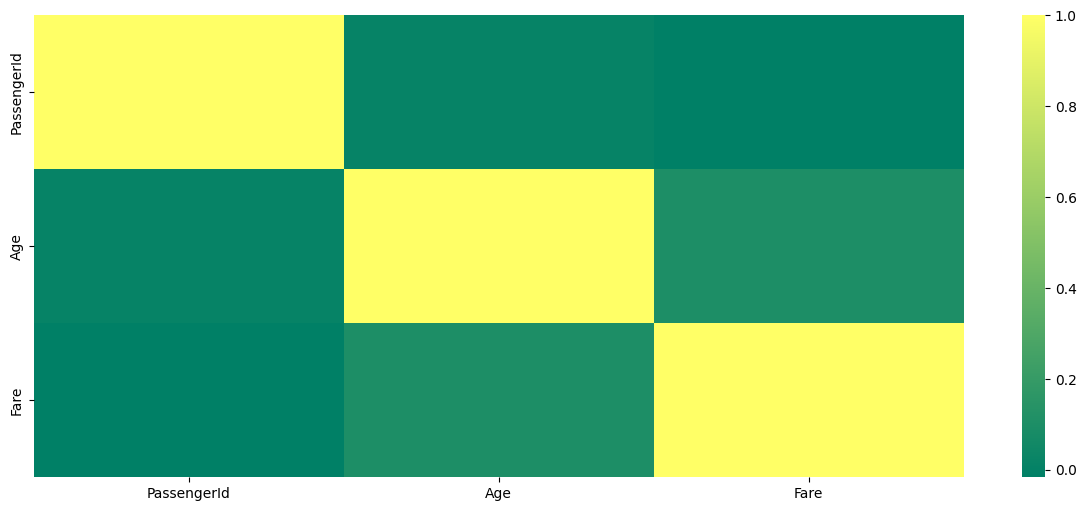

In [49]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), cmap='summer')
plt.show()